In [13]:
import pandas as pd

### load the dataset

In [14]:
df = pd.read_csv("../Dataset/final.csv")

In [15]:
df.head()

,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ecg_peak_freq,resp_peak_freq,temp_slope,eda_slope,label,subject
0,0.872800,0.024465,0.5070,1.1758,-0.132889,0.031347,-0.4014,0.1010,-0.284486,0.047498,...,0.929273,0.025727,0.522995,1.506039,2.200000,0.433333,-0.000012,-0.000033,0,2
1,0.875788,0.059040,0.4826,1.2712,-0.120982,0.078589,-0.4616,0.1268,-0.245599,0.127737,...,0.929947,0.056012,0.496726,1.303793,2.600000,0.066667,-0.000037,-0.000015,0,2
2,0.861583,0.021205,0.7454,1.1624,-0.156330,0.020616,-0.2042,-0.1002,-0.316530,0.031280,...,0.931918,0.018373,0.785213,1.185841,1.300000,0.100000,0.000004,0.000032,0,2
3,0.862690,0.009803,0.7906,0.9224,-0.181321,0.022755,-0.2394,-0.1370,-0.306185,0.014533,...,0.933610,0.007607,0.882272,0.981359,2.466667,0.366667,0.000003,-0.000026,0,2
4,0.857272,0.006321,0.8050,0.9246,-0.188318,0.022537,-0.2520,-0.1382,-0.320673,0.011200,...,0.934800,0.005797,0.882175,0.996625,1.200000,0.400000,-0.000011,-0.000036,0,2


In [16]:
df.drop(columns=['subject'], inplace=True)

In [17]:
accept_label = [1, 2, 3, 4]
df = df[df["label"].isin(accept_label)]
df["label"].value_counts()

label
1    581
4    387
2    326
3    180
Name: count, dtype: int64

In [18]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["label"] = df["label"].apply(apply_target)
df["label"].value_counts()

label
0    1148
1     326
Name: count, dtype: int64

In [21]:
x = df.drop(columns=["label"])
y = df["label"]

### Load the model

In [19]:
import pickle
model = pickle.load(open("../ModelTraining/model.pkl", "rb"))

In [22]:
row = 1

input = x.iloc[row].values.reshape(1, -1)
model.predict(input)

array([0])

### SHAP

In [23]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(x)

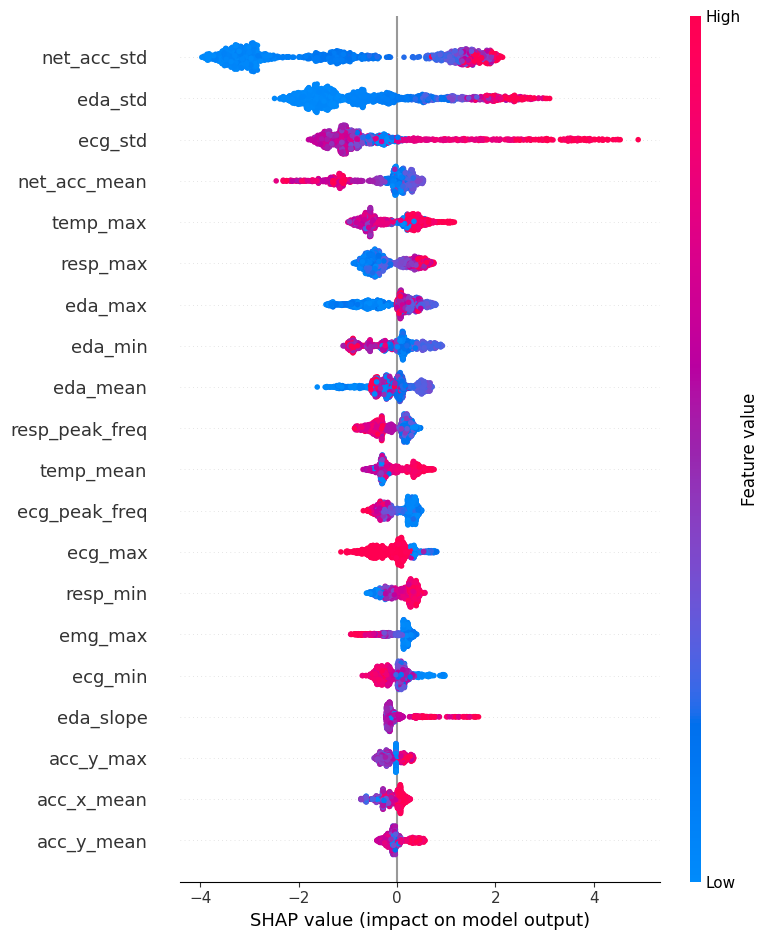

In [24]:
shap.summary_plot(shap_values, x)

### SHAP per class

In [28]:
str = df[df["label"] == 1].drop(columns=["label"])
nstr = df[df["label"] == 0].drop(columns=["label"])

Stress class

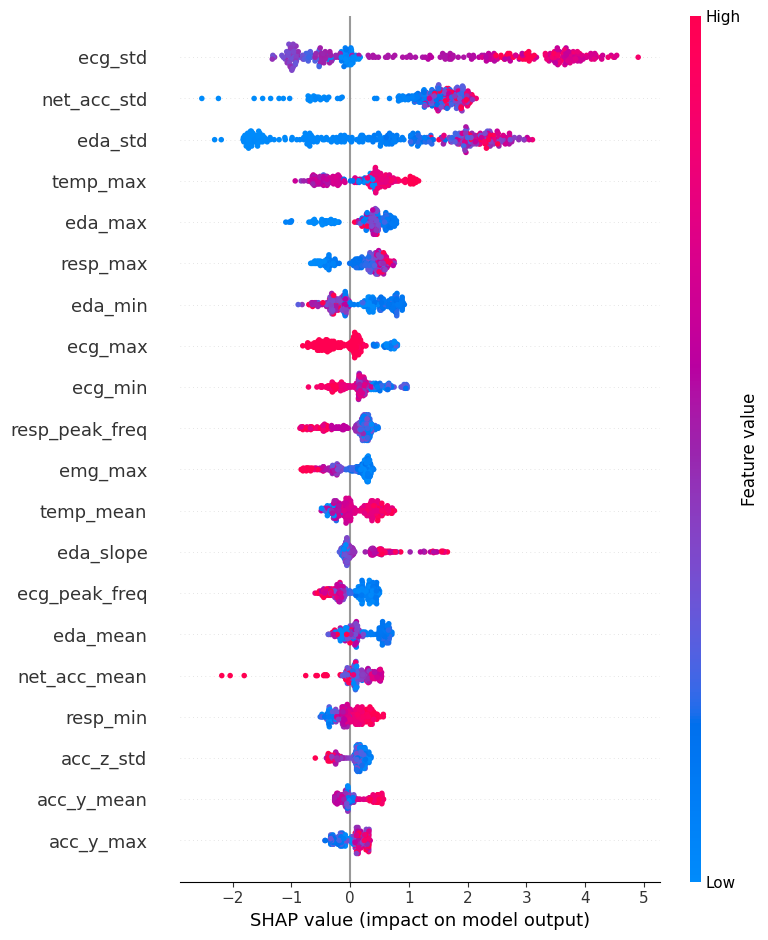

In [29]:
shap_values = explainer(str)
shap.summary_plot(shap_values, str)

Not stress class

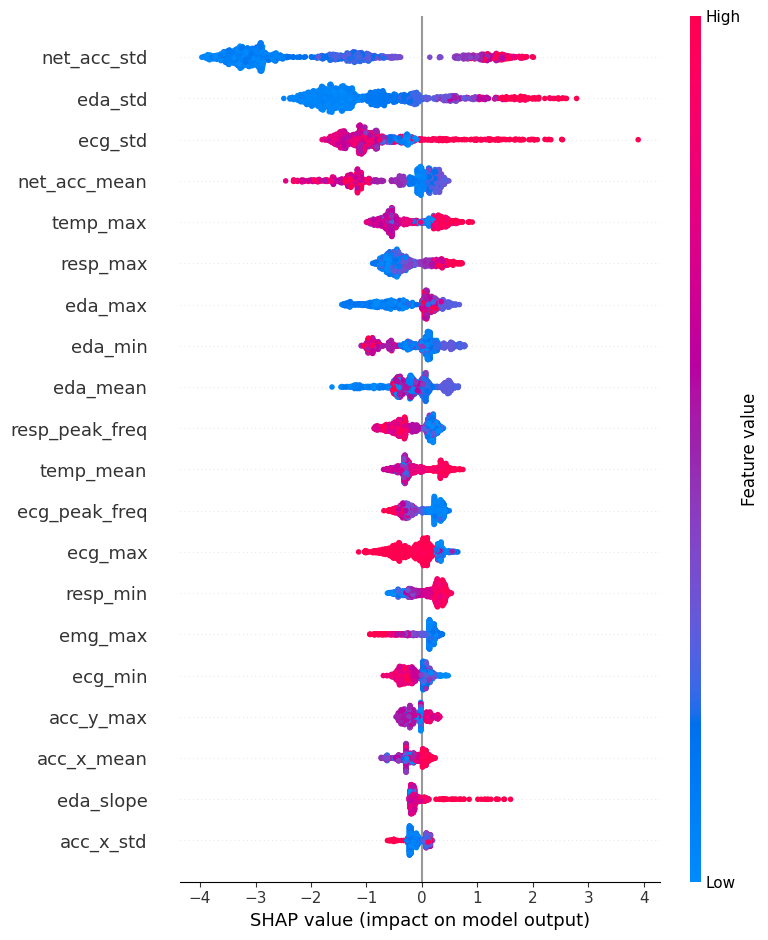

In [30]:
shap_values = explainer(nstr)
shap.summary_plot(shap_values, nstr)

### other plots

waterfall plot

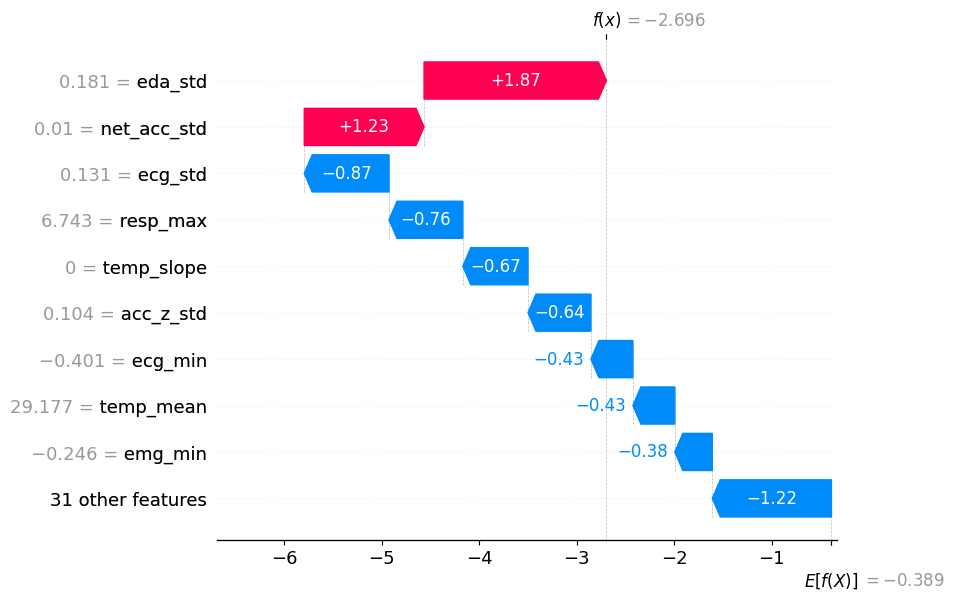

In [36]:
shap_values = explainer(x)
shap.plots.waterfall(shap_values[0])

heatmap

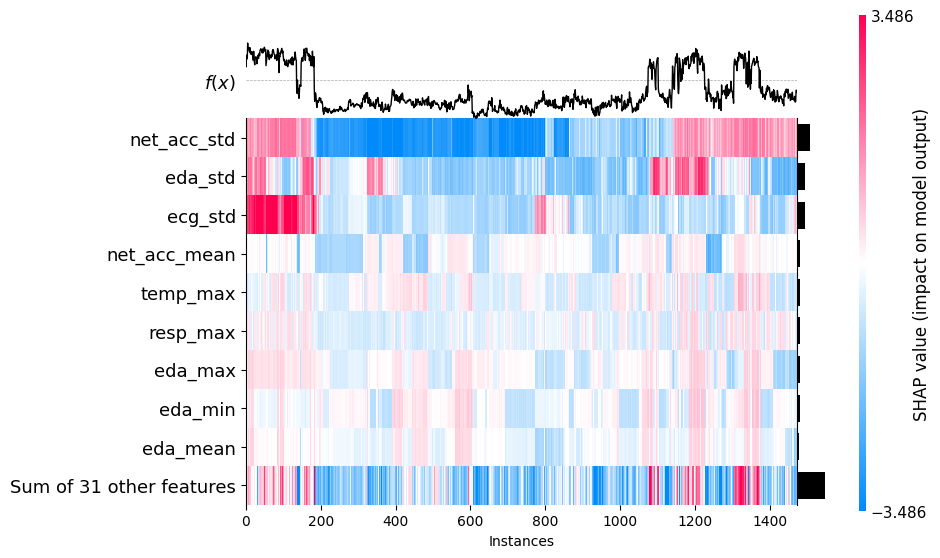

<Axes: xlabel='Instances'>

In [37]:
shap.plots.heatmap(shap_values)

force plot

In [48]:
shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    x.iloc[0]
)